In [1]:
# CELL 1: DATA EXTRACTION
import os
import pandas as pd
import zipfile
import shutil
from sklearn.model_selection import train_test_split

# Setup Kaggle API
os.environ['KAGGLE_API_TOKEN'] = "KGAT_f0b1c8ff434df72d865d509e7cacd6cb"

print("1. Downloading dataset directly from Kaggle... (Takes 3-5 minutes)")
!kaggle datasets download -d nih-chest-xrays/data

local_zip_path = '/content/data.zip' if os.path.exists('/content/data.zip') else '/content/nih-chest-xrays.zip'

print("2. Reading patient records and selecting 2,000 targets...")
with zipfile.ZipFile(local_zip_path, 'r') as z:
    csv_filename = [f for f in z.namelist() if f.endswith('Data_Entry_2017.csv')][0]
    with z.open(csv_filename) as f:
        df = pd.read_csv(f)

normal_df = df[df['Finding Labels'] == 'No Finding'].head(1000)
effusion_df = df[df['Finding Labels'].str.contains('Effusion')].head(1000)
full_df = pd.concat([normal_df, effusion_df])

# Clean Target for safe splitting to avoid the "1 member" error
full_df['Clean_Target'] = full_df['Finding Labels'].apply(lambda x: 'Normal' if x == 'No Finding' else 'Effusion')
train_df, val_df = train_test_split(full_df, test_size=0.2, random_state=42, stratify=full_df['Clean_Target'])

def extract_images(zip_file, dataframe, base_path):
    os.makedirs(os.path.join(base_path, 'Normal'), exist_ok=True)
    os.makedirs(os.path.join(base_path, 'Effusion'), exist_ok=True)
    all_files = {os.path.basename(f): f for f in zip_file.namelist() if f.endswith('.png')}

    count = 0
    for _, row in dataframe.iterrows():
        img_name = row['Image Index']
        label = 'Normal' if row['Finding Labels'] == 'No Finding' else 'Effusion'
        if img_name in all_files:
            source = zip_file.open(all_files[img_name])
            target = open(os.path.join(base_path, label, img_name), "wb")
            with source, target:
                shutil.copyfileobj(source, target)
            count += 1
    return count

print("3. Extracting exactly 2,000 images...")
with zipfile.ZipFile(local_zip_path, 'r') as z:
    train_count = extract_images(z, train_df, '/content/model_data/train')
    val_count = extract_images(z, val_df, '/content/model_data/val')

print("4. PURGING MASSIVE ZIP FILE TO PROTECT STORAGE...")
os.remove(local_zip_path)

print(f"\n✅ DATA EXTRACTION SUCCESS! Training Images: {train_count} | Validation: {val_count}")

1. Downloading dataset directly from Kaggle... (Takes 3-5 minutes)
Dataset URL: https://www.kaggle.com/datasets/nih-chest-xrays/data
License(s): CC0-1.0
100% 42.0G/42.0G [46:11<00:00, 16.3MB/s]

2. Reading patient records and selecting 2,000 targets...
3. Extracting exactly 2,000 images...
4. PURGING MASSIVE ZIP FILE TO PROTECT STORAGE...

✅ DATA EXTRACTION SUCCESS! Training Images: 1600 | Validation: 400


In [2]:
# CELL 2: CONVNEXT VISION SYSTEM (OOM SAFE)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("Setting up the ConvNeXt Vision System...")

train_datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator()

# UPGRADE: Reduced batch_size to 16 to prevent Out of Memory (OOM) GPU crashes
train_generator = train_datagen.flow_from_directory(
    '/content/model_data/train',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    classes=['Normal', 'Effusion']
)

val_generator = val_datagen.flow_from_directory(
    '/content/model_data/val',
    target_size=(224, 224),
    batch_size=16,
    class_mode='binary',
    classes=['Normal', 'Effusion'],
    shuffle=False
)

print("Vision system ready!")

Setting up the ConvNeXt Vision System...
Found 1600 images belonging to 2 classes.
Found 400 images belonging to 2 classes.
Vision system ready!


In [3]:
# CELL 3: CONVNEXT DEEP TRAINING ARCHITECTURE (UPDATED TO .KERAS)
import tensorflow as tf
from tensorflow.keras.applications import ConvNeXtBase
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from google.colab import drive

print("Mounting Google Drive to save the model safely...")
drive.mount('/content/drive')

print("Building the Heavy-Duty ConvNeXt Architecture...")

# Load ConvNeXtBase and unfreeze it
base_model = ConvNeXtBase(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = True

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(1, activation='sigmoid')(x)

model_cx = Model(inputs=base_model.input, outputs=predictions)

# Compiling with a low learning rate
model_cx.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

# THE UPGRADE: Saving as .keras directly to your Google Drive to prevent serialization crashes!
model_save_path = '/content/drive/MyDrive/best_convnext_nih.keras'

checkpoint = ModelCheckpoint(model_save_path, monitor='val_accuracy',
                             save_best_only=True, mode='max', verbose=1)

# The Sniper Scope: drops learning rate if accuracy stalls
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# The Brakes: stops training if overfitting happens
early_stop = EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True)

print("\nStarting ConvNeXt 30-Epoch Deep Training Run...")
history = model_cx.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[checkpoint, reduce_lr, early_stop]
)

print(f"\n✅ Training Complete! Your best ConvNeXt model is safely locked in your Google Drive at: {model_save_path}")

Mounting Google Drive to save the model safely...
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Building the Heavy-Duty ConvNeXt Architecture...

Starting ConvNeXt 30-Epoch Deep Training Run...
Epoch 1/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6090 - loss: 0.6977
Epoch 1: val_accuracy improved from None to 0.72000, saving model to /content/drive/MyDrive/best_convnext_nih.keras

Epoch 1: finished saving model to /content/drive/MyDrive/best_convnext_nih.keras
100/100 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.6369 - loss: 0.6725 - val_accuracy: 0.7200 - val_loss: 0.5806 - learning_rate: 1.0000e-04
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.7077 - loss: 0.5706
Epoch 2: val_accuracy improved from 0.72000 to 0.72250, saving model to /content/drive/MyDrive/best_convnext_nih.keras

Epoch 2: finished saving model to /content/drive/MyDrive/best_convnext_nih.keras
100/100 

Generating Professional Training Curves for ConvNeXt...


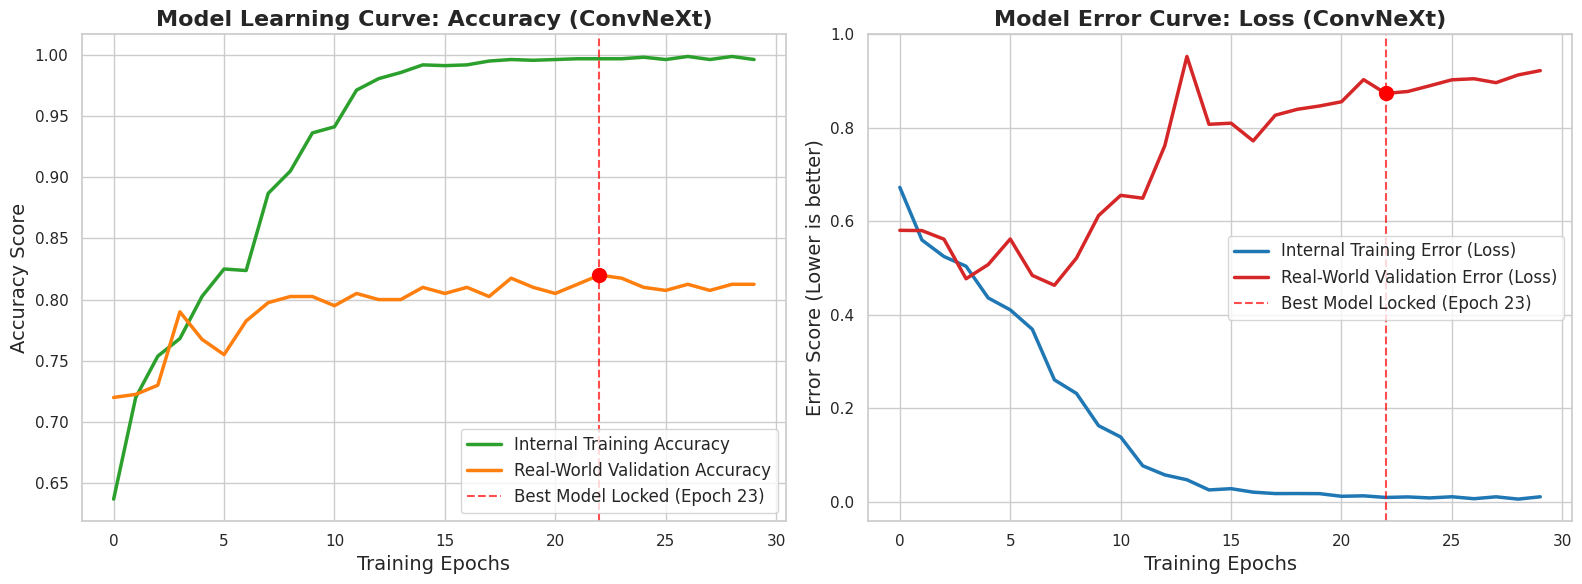


Final Locked Validation Accuracy: 82.00%


In [4]:
# PRESENTATION GRAPHICS: CONVNEXT TRAINING HISTORY
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("Generating Professional Training Curves for ConvNeXt...")

sns.set_theme(style="whitegrid")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Locate the exact highest validation score
best_epoch = np.argmax(history.history['val_accuracy'])
best_val_acc = history.history['val_accuracy'][best_epoch]
best_val_loss = history.history['val_loss'][best_epoch]

# ---------------------------------------------------------
# GRAPH 1: ACCURACY CURVE
# ---------------------------------------------------------
ax1.plot(history.history['accuracy'], label='Internal Training Accuracy', linewidth=2.5, color='#2ca02c')
ax1.plot(history.history['val_accuracy'], label='Real-World Validation Accuracy', linewidth=2.5, color='#ff7f0e')

ax1.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Model Locked (Epoch {best_epoch+1})')
ax1.scatter(best_epoch, best_val_acc, color='red', s=100, zorder=5)

ax1.set_title('Model Learning Curve: Accuracy (ConvNeXt)', fontsize=16, fontweight='bold')
ax1.set_xlabel('Training Epochs', fontsize=14)
ax1.set_ylabel('Accuracy Score', fontsize=14)
ax1.legend(loc='lower right', fontsize=12)

# ---------------------------------------------------------
# GRAPH 2: LOSS (ERROR) CURVE
# ---------------------------------------------------------
ax2.plot(history.history['loss'], label='Internal Training Error (Loss)', linewidth=2.5, color='#1f77b4')
ax2.plot(history.history['val_loss'], label='Real-World Validation Error (Loss)', linewidth=2.5, color='#d62728')

ax2.axvline(x=best_epoch, color='red', linestyle='--', alpha=0.7, label=f'Best Model Locked (Epoch {best_epoch+1})')
ax2.scatter(best_epoch, best_val_loss, color='red', s=100, zorder=5)

ax2.set_title('Model Error Curve: Loss (ConvNeXt)', fontsize=16, fontweight='bold')
ax2.set_xlabel('Training Epochs', fontsize=14)
ax2.set_ylabel('Error Score (Lower is better)', fontsize=14)
ax2.legend(loc='center right', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nFinal Locked Validation Accuracy: {best_val_acc*100:.2f}%")